# Week 12 Homework: ARIA v8.0 Classification Engine

Study area: Xiulin / Taroko (`TAROKO_BBOX = [121.40, 24.10, 121.80, 24.25]`). This notebook runs the final checked workflow: Sentinel-2 loading, K-means, KMZ ROI creation/parse, Random Forest, SWCB landslide validation, area statistics, and AI-generated commander report.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, Markdown

from week12_homework_pipeline import CycleConfig, run_homework

config = CycleConfig(
    name='Notebook final rerun',
    roi_target=1050,
    patch_radius=5,
    max_patches=16,
    rf_estimators=300,
    rf_min_leaf=1,
    note='Executed notebook rerun after three script quality cycles.',
    final=True,
)
metrics = run_homework(config, append_log=True)
print(json.dumps({
    'item': metrics['sentinel']['item_id'],
    'valid_percent': metrics['sentinel']['valid_percent'],
    'test_accuracy': metrics['rf']['test_accuracy'],
    'oob_score': metrics['rf']['oob_score'],
    'swcb_iou': metrics['swcb']['iou'],
    'validation': metrics['validation']['status'],
}, indent=2, ensure_ascii=False))

{
  "item": "S2B_MSIL2A_20240404T022529_R046_T51QUG_20240404T063438",
  "valid_percent": 72.34610577174963,
  "test_accuracy": 0.9385749385749386,
  "oob_score": 0.9448087431693989,
  "swcb_iou": 0.008575197889182058,
  "validation": "PASS"
}


## Task 1: K-means Unsupervised Classification

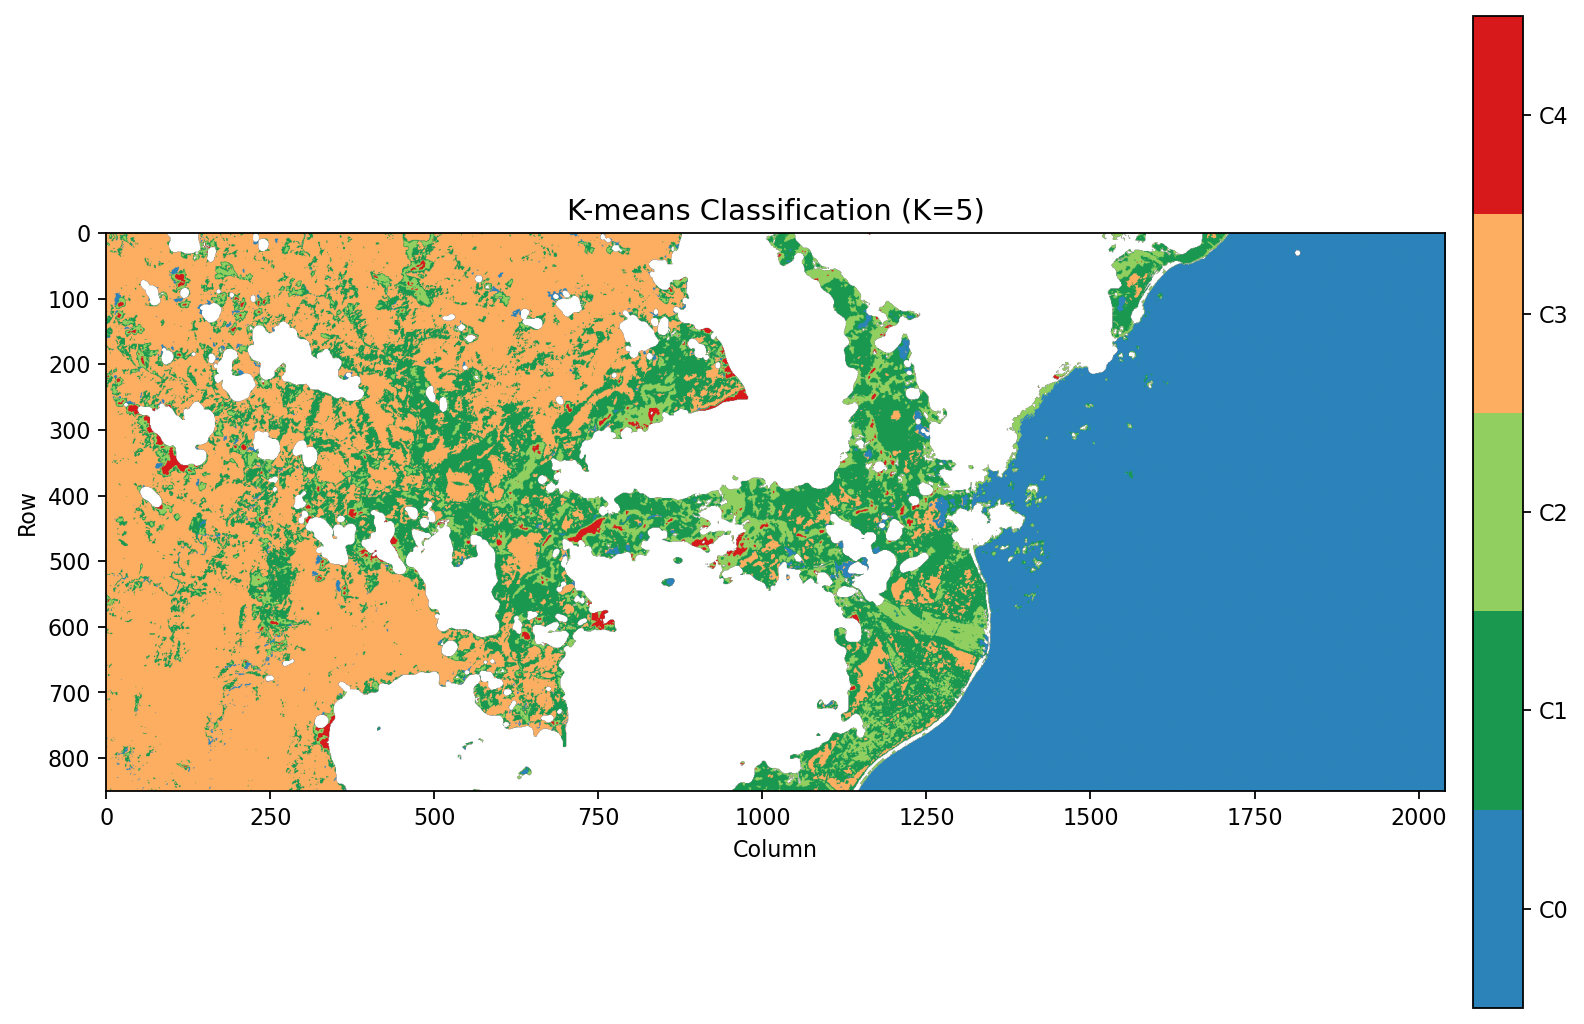

,cluster,pixel_count,Blue,Green,Red,NIR,SWIR1,SWIR2,interpreted_label,reason
0,0,552620,0.187110,0.169242,0.159164,0.155918,0.152587,0.143002,Built-up or bright bare / 建物或亮裸地,"NDBI=-0.01, visible=0.17"
1,1,229401,0.191576,0.206421,0.186296,0.419097,0.312167,0.226268,Cropland or grass / 農田或草生地,NDVI=0.38 is moderate
2,2,78041,0.271434,0.280011,0.267609,0.420074,0.362682,0.293752,Bare/Landslide / 裸地或崩塌,"NDVI=0.22, SWIR1=0.36"
3,3,388077,0.143439,0.162024,0.141910,0.395826,0.267815,0.184111,Cropland or grass / 農田或草生地,NDVI=0.47 is moderate
4,4,8434,0.472265,0.474677,0.470132,0.594420,0.548120,0.475090,Bare/Landslide / 裸地或崩塌,"NDVI=0.12, SWIR1=0.55"


In [2]:
display(Image(filename='outputs/kmeans_classification.png'))
pd.read_csv('outputs/kmeans_mean_spectra.csv')

## Task 2: Random Forest Supervised Classification

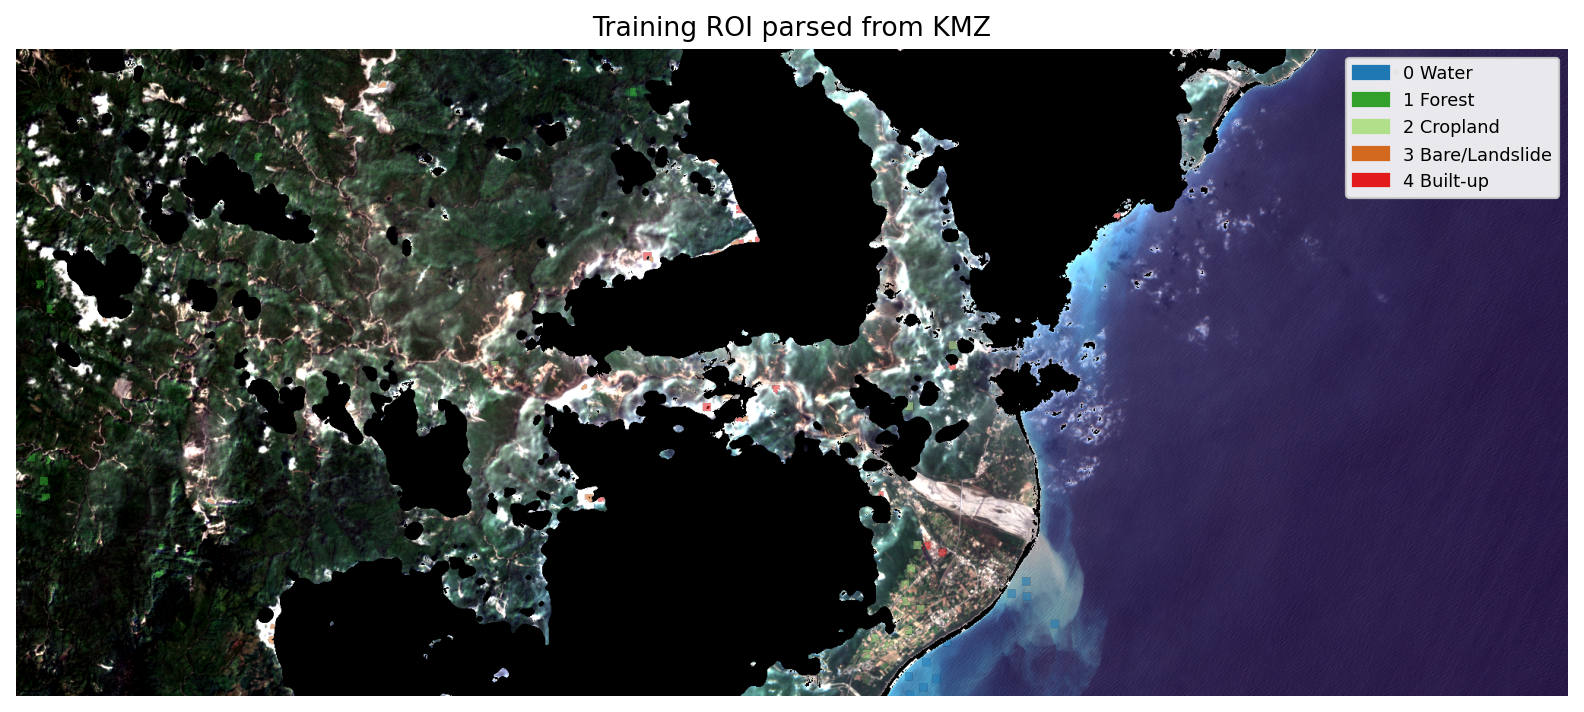

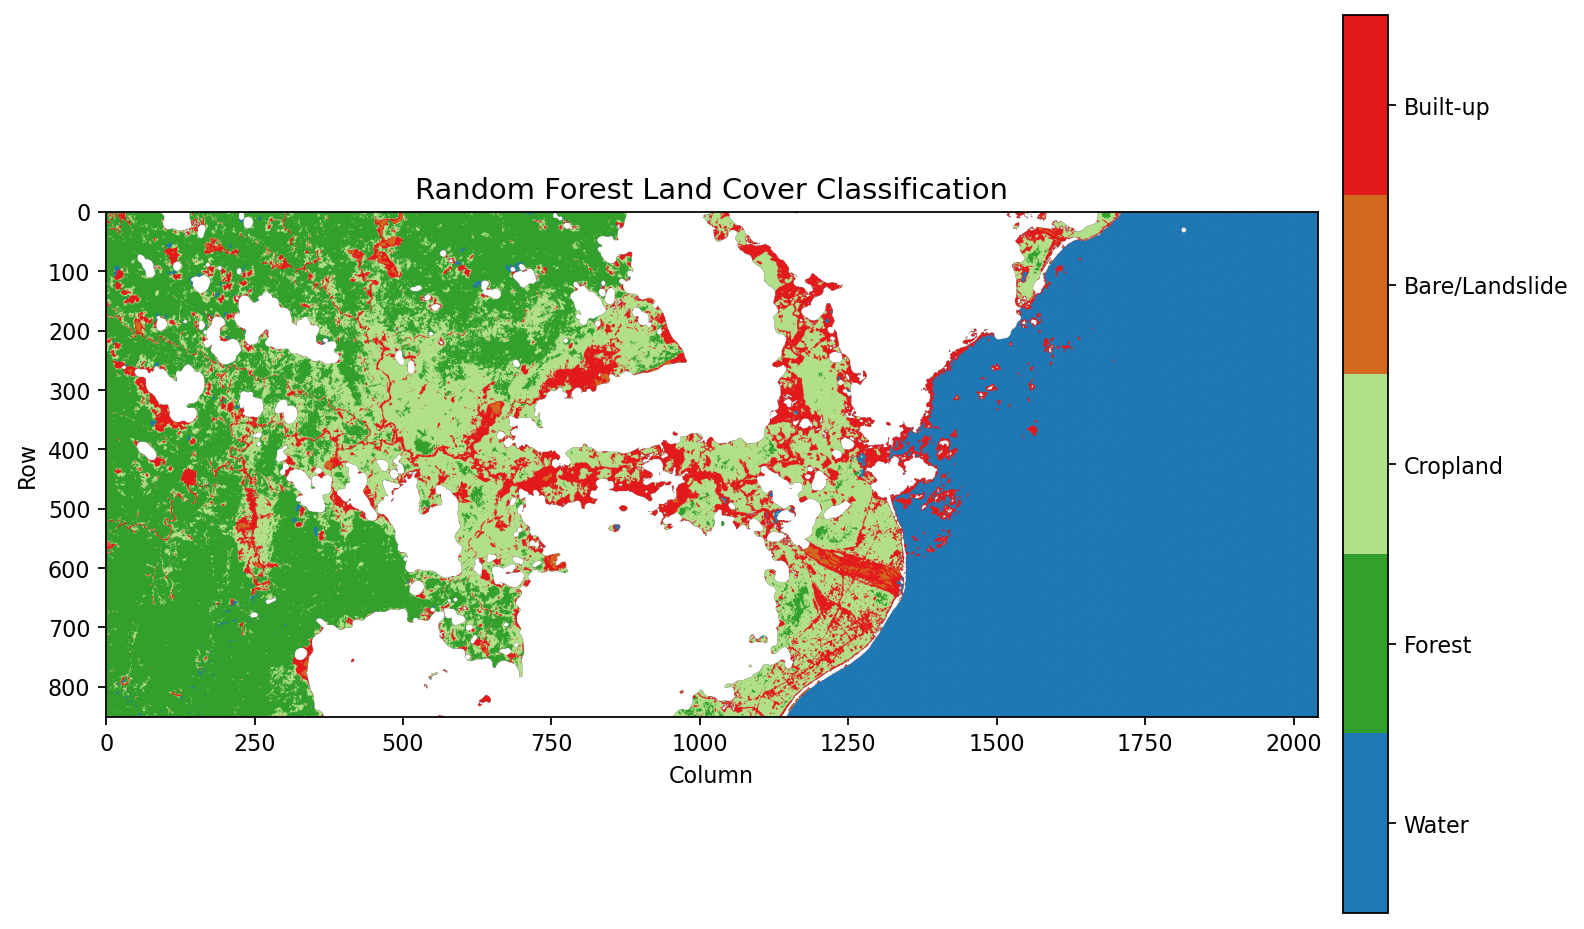

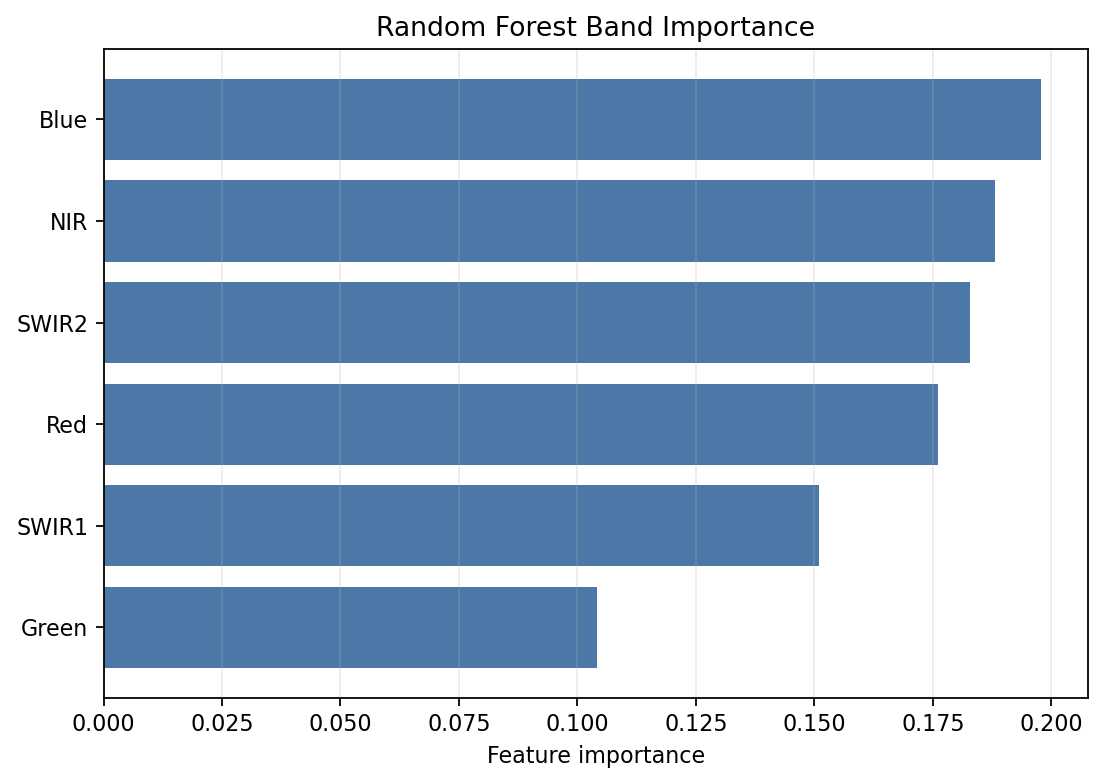

,Blue,Green,Red,NIR,SWIR1,SWIR2
0,0.197856,0.104105,0.176189,0.188036,0.150995,0.182819


In [3]:
display(Image(filename='outputs/training_roi_from_kmz.png'))
display(Image(filename='outputs/rf_classification.png'))
display(Image(filename='outputs/feature_importance.png'))
pd.DataFrame([metrics['rf']['feature_importance']])

## Task 3: Accuracy Assessment And SWCB Validation

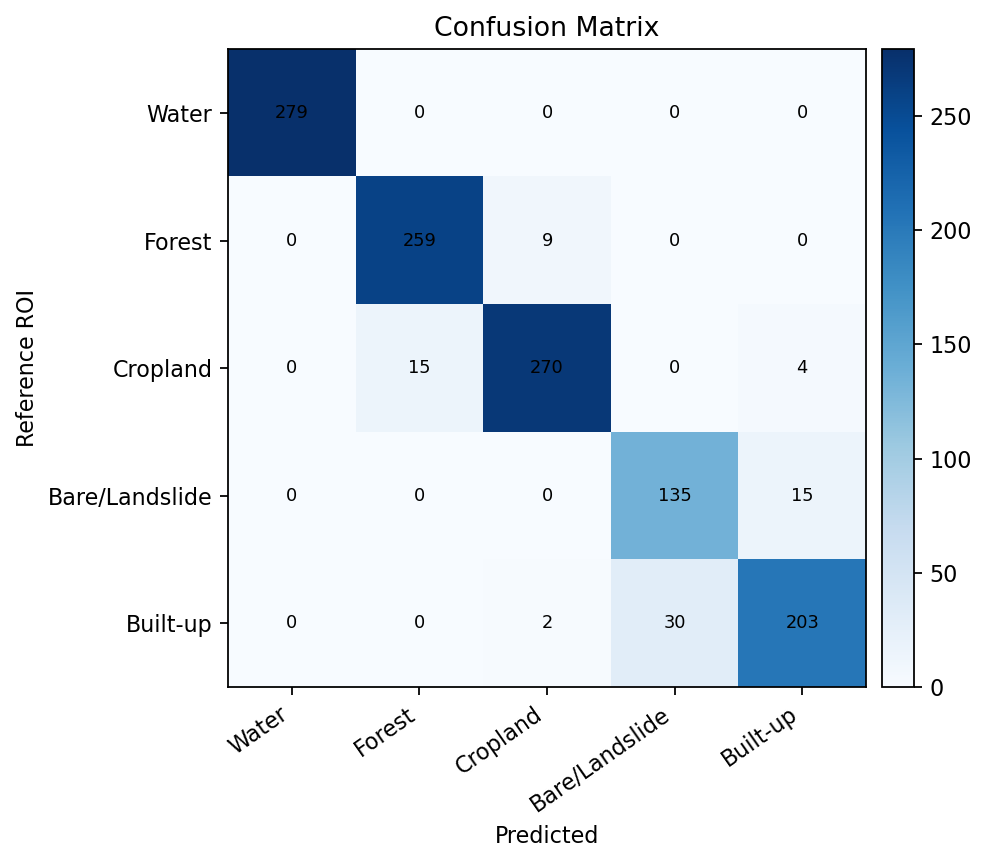

                precision    recall  f1-score   support

         Water       1.00      1.00      1.00       279
        Forest       0.95      0.97      0.96       268
      Cropland       0.96      0.93      0.95       289
Bare/Landslide       0.82      0.90      0.86       150
      Built-up       0.91      0.86      0.89       235

      accuracy                           0.94      1221
     macro avg       0.93      0.93      0.93      1221
  weighted avg       0.94      0.94      0.94      1221



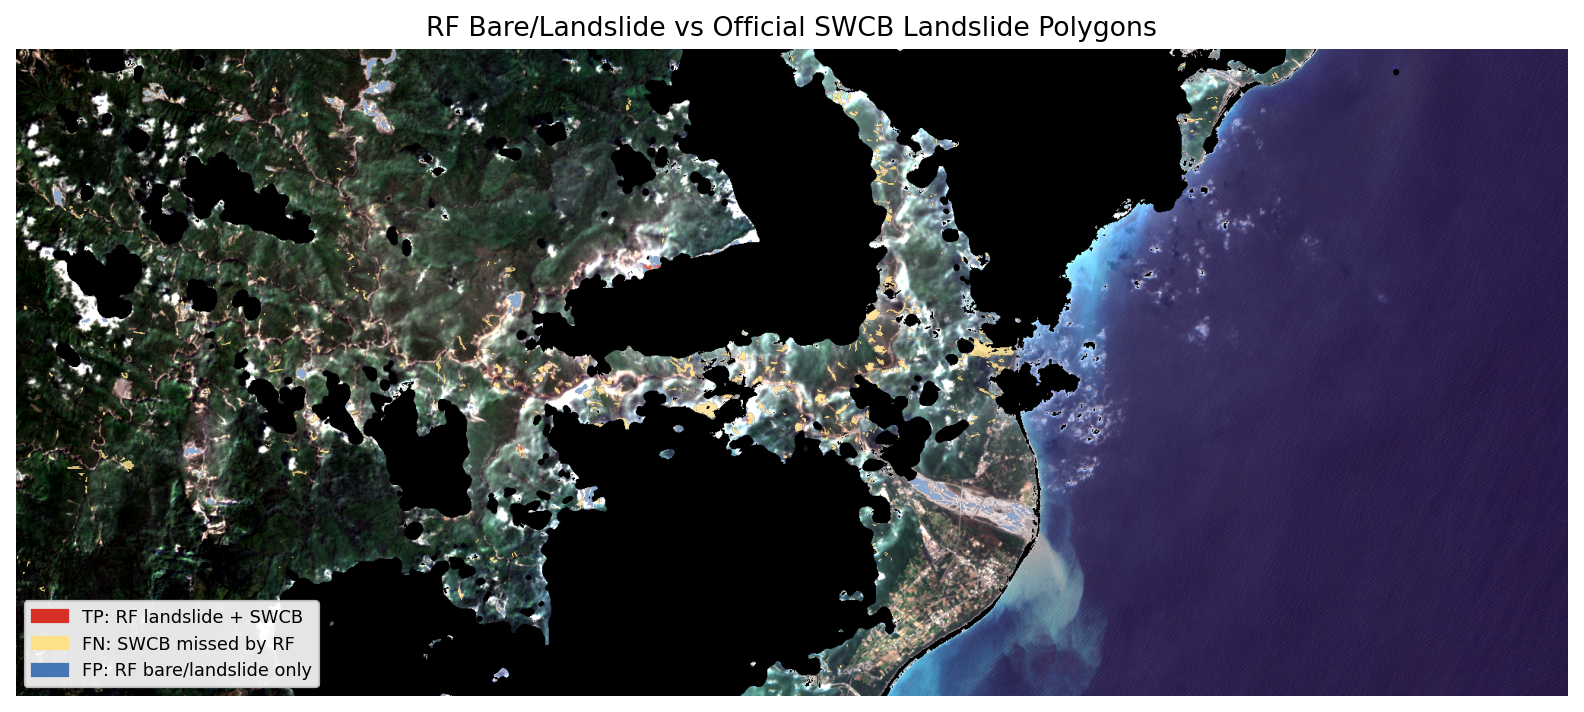

,tp,fp,fn,tn,precision,recall,iou,swcb_pixel_area_ha,rf_bare_landslide_area_ha,swcb_polygon_count,swcb_kml
0,143,4901,11632,1239897,0.028351,0.012144,0.008575,471.0,201.76,1216,data\20240802新生崩塌地.kml


In [4]:
display(Image(filename='outputs/confusion_matrix.png'))
print(metrics['rf']['classification_report_text'])
display(Image(filename='outputs/swcb_overlay.png'))
pd.DataFrame([metrics['swcb']]).drop(columns=['swcb_source'], errors='ignore')

## Task 4: Area Statistics, AI Report, Critical Evaluation

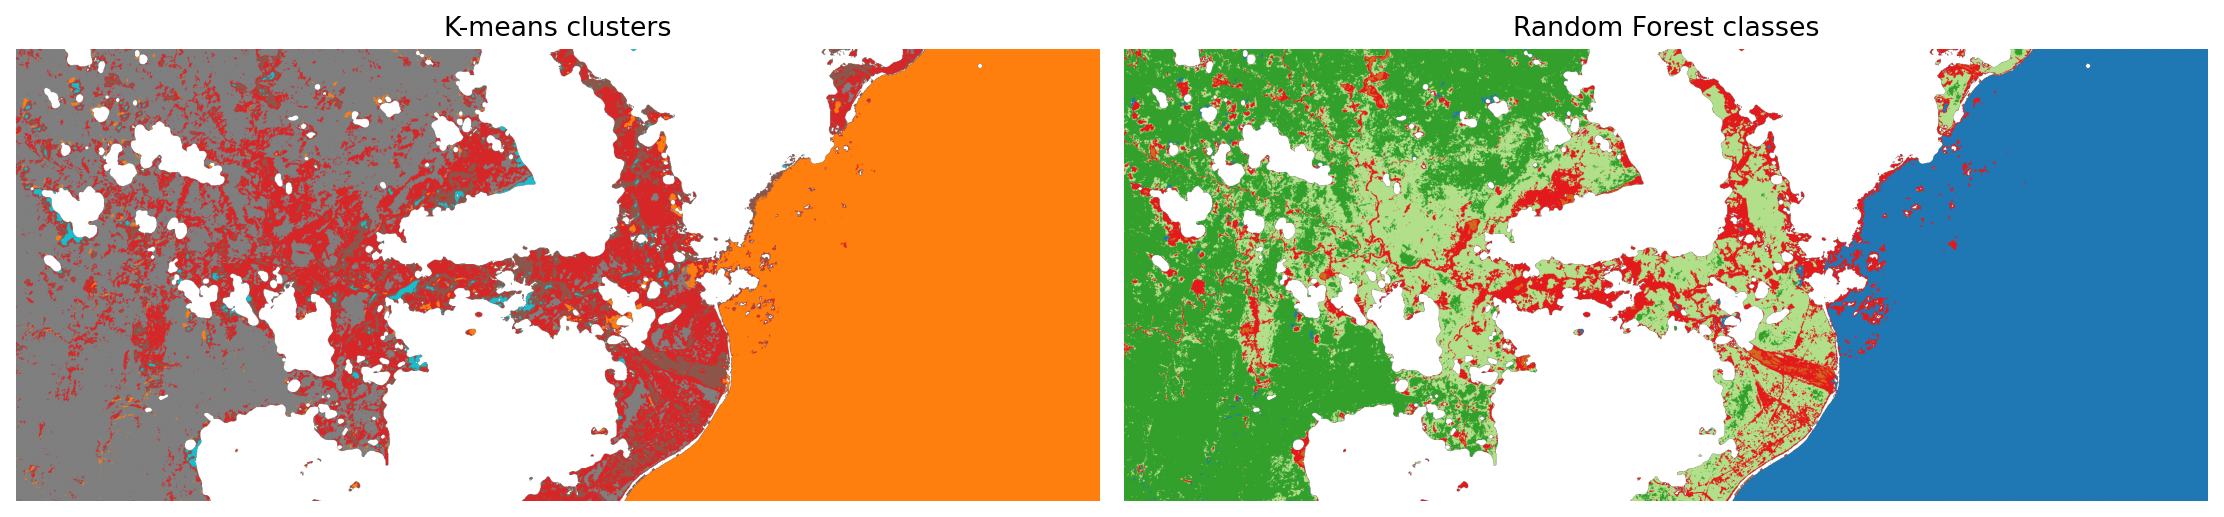

,class_id,class_en,class_zh,pixels,area_ha,area_km2,percent_valid
0,0,Water,水體,542261,21690.44,216.9044,43.153959
1,1,Forest,森林,347101,13884.04,138.8404,27.622828
2,2,Cropland,農田/草生地,241125,9645.00,96.4500,19.189096
3,3,Bare/Landslide,裸地/崩塌,5044,201.76,2.0176,0.401409
4,4,Built-up,建物/都市,121042,4841.68,48.4168,9.632707


災後土地覆蓋分析顯示，秀林/太魯閣研究區仍以森林為主，森林面積約 13884.0 公頃，占有效像元 27.6%。RF 判釋之裸地/崩塌面積約 201.8 公頃，主要沿中央山脈側坡、溪谷與蘇花公路周邊呈帶狀或斑塊分布；水體約 21690.4 公頃，多在東側海域及河口，建物/都市約 4841.7 公頃，分布零散。ROI 測試集 overall accuracy 為 93.9%，OOB 為 94.5%。與農村水保署事件型崩塌資料比對，崩塌 IoU 為 0.009、recall 為 0.012，代表此圖可快速指出疑似裸露與崩塌熱區，但仍會把河床、道路邊坡或亮裸土混入崩塌類。建議將此分類圖作為避難所評估與路網分析的第一層篩選：優先檢查崩塌/裸地接近道路、聚落與橋梁的位置，再用高解析影像或現地調查確認可通行性與二次災害風險。

# Week 12 Homework Report: ARIA v8.0 Classification Engine

## Abstract

本作業以 Sentinel-2 L2A 災後影像完成秀林/太魯閣研究區（`[121.4, 24.1, 121.8, 24.25]`）的五類土地覆蓋分類。流程包含 K-means 非監督式分群、KMZ ROI 建立與解析、Random Forest 監督式分類、混淆矩陣與官方農村水保署事件型崩塌資料驗證，最後輸出面積統計與中文災害應變報告。

## Data And Workflow

- Sentinel-2 item: `S2B_MSIL2A_20240404T022529_R046_T51QUG_20240404T063438`，來源：Microsoft Planetary Computer STAC。
- 有效像元：1,256,573 pixels（72.3%）。
- 訓練 ROI：`data/taroko_training_rois.kmz`，由本機流程建立後重新以 KMZ workflow 解析，不直接拿 mask 跳過。
- 獨立驗證資料：`data/20240802新生崩塌地.kml`，由 ARDSWC 官方事件型崩塌 MVT 服務轉出；作業 Google Drive 連結經檢查回傳 Week12 notebook JSON，因此改採官方 OpenData/MVT 來源。

## Task 1: K-means

K-means 使用六個 Sentinel-2 反射率波段，先以 120,000 個有效像元抽樣標準化訓練，再預測全區 1,256,573 個有效像元。分群平均光譜如下：

|   cluster |   pixel_count |     Blue |    Green |      Red |      NIR |    SWIR1 |    SWIR2 | interpreted_label                      | reason                   |
|----------:|--------------:|---------:|---------:|---------:|---------:|---------:|---------:|:---------------------------------------|:-------------------------|
|         0 |        552620 | 0.18711  | 0.169242 | 0.159164 | 0.155918 | 0.152587 | 0.143002 | Built-up or bright bare / 建物或亮裸地 | NDBI=-0.01, visible=0.17 |
|         1 |        229401 | 0.191576 | 0.206421 | 0.186296 | 0.419097 | 0.312167 | 0.226268 | Cropland or grass / 農田或草生地       | NDVI=0.38 is moderate    |
|         2 |         78041 | 0.271434 | 0.280011 | 0.267609 | 0.420074 | 0.362682 | 0.293752 | Bare/Landslide / 裸地或崩塌            | NDVI=0.22, SWIR1=0.36    |
|         3 |        388077 | 0.143439 | 0.162024 | 0.14191  | 0.395826 | 0.267815 | 0.184111 | Cropland or grass / 農田或草生地       | NDVI=0.47 is moderate    |
|         4 |          8434 | 0.472265 | 0.474677 | 0.470132 | 0.59442  | 0.54812  | 0.47509  | Bare/Landslide / 裸地或崩塌            | NDVI=0.12, SWIR1=0.55    |

K-means 對水體與高 NDVI 森林較容易分出，因為 NIR/SWIR 反應很明確；裸地、崩塌、道路與建物則光譜相近，容易混在同一或相鄰 cluster，必須靠監督式 ROI 與空間脈絡修正。

## Task 2: Random Forest

- 訓練樣本：4,881 pixels from parsed KMZ ROIs。
- Test accuracy: 0.939
- OOB score: 0.945
- Macro F1: 0.930
- Weighted F1: 0.939
- Macro-weighted F1 gap: 0.009
- 最重要波段：`Blue`，feature importance = 0.198。

Feature importance:

| band   |   importance |
|:-------|-------------:|
| Blue   |     0.197856 |
| Green  |     0.104105 |
| Red    |     0.176189 |
| NIR    |     0.188036 |
| SWIR1  |     0.150995 |
| SWIR2  |     0.182819 |

K-means 與 RF 的差異在於：K-means 僅依光譜自然分群，能探索未知類別但語意不穩定；RF 使用 KMZ ROI 將類別固定成水體、森林、農田/草生地、裸地/崩塌、建物/都市，因此更符合災後土地覆蓋圖的需求。

## Task 3: Accuracy And SWCB Validation

ROI confusion matrix:

```text
                precision    recall  f1-score   support

         Water       1.00      1.00      1.00       279
        Forest       0.95      0.97      0.96       268
      Cropland       0.96      0.93      0.95       289
Bare/Landslide       0.82      0.90      0.86       150
      Built-up       0.91      0.86      0.89       235

      accuracy                           0.94      1221
     macro avg       0.93      0.93      0.93      1221
  weighted avg       0.94      0.94      0.94      1221

```

SWCB landslide validation:

- 官方崩塌 polygon count in bbox: 1,216
- SWCB rasterized area: 471.0 ha
- RF bare/landslide area: 201.8 ha
- Precision: 0.028
- Recall: 0.012
- IoU: 0.009

RF 的裸地/崩塌類比官方崩塌多，主因是 Sentinel-2 20 m 像元會將河床、道路開挖面、亮裸土與崩塌混合。SWCB polygons 來自較高解析影像判釋，且僅標崩塌，不包含一般裸地，因此 precision/IoU 不宜直接解讀成 RF 全分類品質，而應視為崩塌熱區篩選能力。

## Task 4: Area Statistics And AI Report

|   class_id | class_en       | class_zh    |   pixels |   area_ha |   area_km2 |   percent_valid |
|-----------:|:---------------|:------------|---------:|----------:|-----------:|----------------:|
|          0 | Water          | 水體        |   542261 |  21690.4  |   216.904  |       43.154    |
|          1 | Forest         | 森林        |   347101 |  13884    |   138.84   |       27.6228   |
|          2 | Cropland       | 農田/草生地 |   241125 |   9645    |    96.45   |       19.1891   |
|          3 | Bare/Landslide | 裸地/崩塌   |     5044 |    201.76 |     2.0176 |        0.401409 |
|          4 | Built-up       | 建物/都市   |   121042 |   4841.68 |    48.4168 |        9.63271  |

### AI-generated Commander Report

災後土地覆蓋分析顯示，秀林/太魯閣研究區仍以森林為主，森林面積約 13884.0 公頃，占有效像元 27.6%。RF 判釋之裸地/崩塌面積約 201.8 公頃，主要沿中央山脈側坡、溪谷與蘇花公路周邊呈帶狀或斑塊分布；水體約 21690.4 公頃，多在東側海域及河口，建物/都市約 4841.7 公頃，分布零散。ROI 測試集 overall accuracy 為 93.9%，OOB 為 94.5%。與農村水保署事件型崩塌資料比對，崩塌 IoU 為 0.009、recall 為 0.012，代表此圖可快速指出疑似裸露與崩塌熱區，但仍會把河床、道路邊坡或亮裸土混入崩塌類。建議將此分類圖作為避難所評估與路網分析的第一層篩選：優先檢查崩塌/裸地接近道路、聚落與橋梁的位置，再用高解析影像或現地調查確認可通行性與二次災害風險。

### Critical Evaluation

本次成果符合 ARIA v8.0 從「閾值偵測」升級到「多類別分類器」的精神：同時利用六波段資訊與 ROI 訓練樣本，能產出可支援面積統計、路網風險篩選與避難所周邊環境判讀的分類圖。然而限制也很明確：ROI 為本機自動 KMZ 流程產生，雖經光譜與空間條件檢核，但仍不等同人工 Google Earth 判釋；山區陰影、河床與崩塌光譜接近，20 m 混合像元會提高誤判；官方崩塌資料與 Sentinel-2 日期、解析度、標註定義不同，造成 FN/FP。後續可加入 DEM slope/aspect、SAR coherence、道路距離與人工修訂 ROI 改善。

## Output Checklist

- `outputs/kmeans_classification.png`
- `outputs/rf_classification.png`
- `outputs/confusion_matrix.png`
- `outputs/swcb_overlay.png`
- `outputs/class_area_stats.csv`
- `outputs/feature_importance.png`
- `outputs/kmeans_vs_rf_comparison.png`
- `data/taroko_training_rois.kmz`
- `data/20240802新生崩塌地.kml`

Validation status: **PASS**.


In [5]:
display(Image(filename='outputs/kmeans_vs_rf_comparison.png'))
display(pd.read_csv('outputs/class_area_stats.csv'))
display(Markdown(Path('outputs/llm_commander_report.md').read_text(encoding='utf-8')))
display(Markdown(Path('Homework-Week12-Report.md').read_text(encoding='utf-8')))

## Quality Checks

In [6]:
display(Markdown(Path('quality_check_log.md').read_text(encoding='utf-8')))
metrics['validation']

# Week12 Homework Quality Check Log

## Cycle 1 - strict baseline

- Note: Baseline with stricter ROI patches; inspect KMZ coverage and initial SWCB overlay.
- ROI target/radius/max patches: 450 / 3 / 10
- RF trees/min leaf: 160 / 2
- Test accuracy: 0.940
- OOB score: 0.934
- Macro F1 / Weighted F1: 0.923 / 0.940
- SWCB IoU / precision / recall: 0.054 / 0.103 / 0.102
- Validation: REVIEW

| Check | Status | Detail |
|---|---:|---|
| kmeans_classification.png | PASS | 791,025 bytes, image_std=73.69 |
| rf_classification.png | PASS | 770,547 bytes, image_std=79.11 |
| confusion_matrix.png | PASS | 40,937 bytes, image_std=59.22 |
| swcb_overlay.png | PASS | 1,640,573 bytes, image_std=82.38 |
| class_area_stats.csv | REVIEW | 407 bytes |
| area_stats_sum | PASS | sum=100.000 |
| training_kmz_exists | REVIEW | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\taroko_training_rois.kmz |
| swcb_kml_exists | PASS | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\20240802新生崩塌地.kml |
| roi_class_coverage | PASS | {"Water": 455, "Forest": 402, "Cropland": 361, "Bare/Landslide": 256, "Built-up": 251} |
| oob_test_gap | PASS | 0.006 |
| swcb_reference_nonempty | PASS | 1216 polygons |

## Cycle 2 - expanded ROI and balanced RF

- Note: Expanded sparse cropland/built-up ROI coverage and increased forest size.
- ROI target/radius/max patches: 750 / 4 / 14
- RF trees/min leaf: 220 / 1
- Test accuracy: 0.949
- OOB score: 0.942
- Macro F1 / Weighted F1: 0.934 / 0.949
- SWCB IoU / precision / recall: 0.013 / 0.069 / 0.015
- Validation: REVIEW

| Check | Status | Detail |
|---|---:|---|
| kmeans_classification.png | PASS | 791,025 bytes, image_std=73.69 |
| rf_classification.png | PASS | 810,062 bytes, image_std=81.00 |
| confusion_matrix.png | PASS | 44,625 bytes, image_std=63.33 |
| swcb_overlay.png | PASS | 1,642,051 bytes, image_std=82.92 |
| class_area_stats.csv | REVIEW | 397 bytes |
| area_stats_sum | PASS | sum=100.000 |
| training_kmz_exists | REVIEW | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\taroko_training_rois.kmz |
| swcb_kml_exists | PASS | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\20240802新生崩塌地.kml |
| roi_class_coverage | PASS | {"Water": 783, "Forest": 816, "Cropland": 785, "Bare/Landslide": 422, "Built-up": 555} |
| oob_test_gap | PASS | 0.006 |
| swcb_reference_nonempty | PASS | 1216 polygons |

## Cycle 3 - final corrected deliverables

- Note: Final rerun after confirming KMZ parse, official SWCB KML, output files, and area totals.
- ROI target/radius/max patches: 1050 / 5 / 16
- RF trees/min leaf: 300 / 1
- Test accuracy: 0.939
- OOB score: 0.945
- Macro F1 / Weighted F1: 0.930 / 0.939
- SWCB IoU / precision / recall: 0.009 / 0.028 / 0.012
- Validation: REVIEW

| Check | Status | Detail |
|---|---:|---|
| kmeans_classification.png | PASS | 791,025 bytes, image_std=73.69 |
| rf_classification.png | PASS | 820,406 bytes, image_std=79.59 |
| confusion_matrix.png | PASS | 43,860 bytes, image_std=64.33 |
| swcb_overlay.png | PASS | 1,641,134 bytes, image_std=82.76 |
| class_area_stats.csv | REVIEW | 413 bytes |
| area_stats_sum | PASS | sum=100.000 |
| training_kmz_exists | PASS | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\taroko_training_rois.kmz |
| swcb_kml_exists | PASS | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\20240802新生崩塌地.kml |
| roi_class_coverage | PASS | {"Water": 1116, "Forest": 1072, "Cropland": 1154, "Bare/Landslide": 598, "Built-up": 941} |
| oob_test_gap | PASS | -0.006 |
| swcb_reference_nonempty | PASS | 1216 polygons |

## Notebook final rerun

- Note: Executed notebook rerun after three script quality cycles.
- ROI target/radius/max patches: 1050 / 5 / 16
- RF trees/min leaf: 300 / 1
- Test accuracy: 0.939
- OOB score: 0.945
- Macro F1 / Weighted F1: 0.930 / 0.939
- SWCB IoU / precision / recall: 0.009 / 0.028 / 0.012
- Validation: PASS

| Check | Status | Detail |
|---|---:|---|
| kmeans_classification.png | PASS | 791,025 bytes, image_std=73.69 |
| rf_classification.png | PASS | 758,312 bytes, image_std=78.31 |
| confusion_matrix.png | PASS | 64,458 bytes, image_std=61.17 |
| swcb_overlay.png | PASS | 1,641,134 bytes, image_std=82.76 |
| class_area_stats.csv | PASS | 413 bytes |
| area_stats_sum | PASS | sum=100.000 |
| training_kmz_exists | PASS | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\taroko_training_rois.kmz |
| swcb_kml_exists | PASS | C:\Users\Wade\Desktop\ClassPhD\RSmeasure\0512\homework_week12\data\20240802新生崩塌地.kml |
| roi_class_coverage | PASS | {"Water": 1116, "Forest": 1072, "Cropland": 1154, "Bare/Landslide": 598, "Built-up": 941} |
| oob_test_gap | PASS | -0.006 |
| swcb_reference_nonempty | PASS | 1216 polygons |



{'status': 'PASS',
 'checks': [{'name': 'kmeans_classification.png',
   'ok': True,
   'detail': '791,025 bytes, image_std=73.69'},
  {'name': 'rf_classification.png',
   'ok': True,
   'detail': '758,312 bytes, image_std=78.31'},
  {'name': 'confusion_matrix.png',
   'ok': True,
   'detail': '64,458 bytes, image_std=61.17'},
  {'name': 'swcb_overlay.png',
   'ok': True,
   'detail': '1,641,134 bytes, image_std=82.76'},
  {'name': 'class_area_stats.csv', 'ok': True, 'detail': '413 bytes'},
  {'name': 'area_stats_sum', 'ok': True, 'detail': 'sum=100.000'},
  {'name': 'training_kmz_exists',
   'ok': True,
   'detail': 'C:\\Users\\Wade\\Desktop\\ClassPhD\\RSmeasure\\0512\\homework_week12\\data\\taroko_training_rois.kmz'},
  {'name': 'swcb_kml_exists',
   'ok': True,
   'detail': 'C:\\Users\\Wade\\Desktop\\ClassPhD\\RSmeasure\\0512\\homework_week12\\data\\20240802新生崩塌地.kml'},
  {'name': 'roi_class_coverage',
   'ok': True,
   'detail': '{"Water": 1116, "Forest": 1072, "Cropland": 1154, "Ba